In [6]:
import os
import json
import random
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import pywt
import mne
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


## 2. Вспомогательные функции


In [7]:
from pathlib import Path
import os

# ابحث تلقائياً عن ملفات edf داخل /kaggle/input
all_edf_files = []
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        if filename.lower().endswith(".edf"):
            all_edf_files.append(os.path.join(dirname, filename))

print("EDF files found:")
for f in all_edf_files:
    print(f)

if len(all_edf_files) == 0:
    raise FileNotFoundError("No EDF files were found in /kaggle/input")

# خذ أول مجلد يحتوي ملفات edf
DATA_DIR = Path(os.path.dirname(all_edf_files[0]))
print("\nDetected DATA_DIR =", DATA_DIR)

WORK_DIR = Path("/kaggle/working/lab4_variant")
IMG_ROOT = WORK_DIR / "dataset_images"
SEIZ_DIR = IMG_ROOT / "seizure"
NON_DIR = IMG_ROOT / "non_seizure"
PLOTS_DIR = WORK_DIR / "plots"
MODEL_DIR = WORK_DIR / "models"

for d in [SEIZ_DIR, NON_DIR, PLOTS_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

FILE_META = {
    "chb08_11.edf": [(2988, 3122)],
    "chb08_13.edf": [(2417, 2577)],
    "chb08_21.edf": [(2083, 2347)],
    "chb08_12.edf": [],
    "chb08_14.edf": [],
    "chb08_15.edf": [],
}

SEIZURE_FILES = ["chb08_11.edf", "chb08_13.edf", "chb08_21.edf"]
BACKGROUND_FILES = ["chb08_12.edf", "chb08_14.edf", "chb08_15.edf"]

SEGMENT_SEC = 3
TARGET_PER_CLASS = 60
IMG_SIZE = 160
FS_EXPECTED = 256
LOWPASS_HZ = 60

# تحقق من وجود الملفات المطلوبة
required_files = SEIZURE_FILES + BACKGROUND_FILES
missing_files = [f for f in required_files if not (DATA_DIR / f).exists()]

print("\nChecking required files...")
if missing_files:
    print("Missing files:", missing_files)
    raise FileNotFoundError(f"These files are missing: {missing_files}")
else:
    print("All required files are present.")

EDF files found:
/kaggle/input/datasets/ahmadhamed1046/chb08-files/chb08_13.edf
/kaggle/input/datasets/ahmadhamed1046/chb08-files/chb08_15.edf
/kaggle/input/datasets/ahmadhamed1046/chb08-files/chb08_11.edf
/kaggle/input/datasets/ahmadhamed1046/chb08-files/chb08_12.edf
/kaggle/input/datasets/ahmadhamed1046/chb08-files/chb08_21.edf
/kaggle/input/datasets/ahmadhamed1046/chb08-files/chb08_14.edf

Detected DATA_DIR = /kaggle/input/datasets/ahmadhamed1046/chb08-files

Checking required files...
All required files are present.


## 3. Формирование выборки изображений


In [8]:
def load_avg_signal(edf_path):
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    sfreq = int(raw.info["sfreq"])
    try:
        data = raw.copy().pick("eeg").get_data()
    except Exception:
        data = raw.get_data()
    avg_signal = data.mean(axis=0).astype(np.float32)
    return avg_signal, sfreq, raw.ch_names

def lowpass_filter(x, sfreq, cutoff=60.0, order=4):
    nyq = 0.5 * sfreq
    normal_cutoff = min(cutoff / nyq, 0.99)
    b, a = butter(order, normal_cutoff, btype="low")
    return filtfilt(b, a, x)

def build_scalogram(segment, sfreq, img_size=160, scales=np.arange(1, 49)):
    coeffs, freqs = pywt.cwt(segment, scales, "morl", sampling_period=1/sfreq)
    scal = np.abs(coeffs)
    scal = np.flipud(scal)
    scal = (scal - scal.min()) / (scal.max() - scal.min() + 1e-8)
    rgba = plt.cm.magma(scal)
    rgb = (rgba[:, :, :3] * 255).astype(np.uint8)
    img = Image.fromarray(rgb).resize((img_size, img_size))
    return img

def save_segment_image(segment, sfreq, out_path, img_size=160):
    img = build_scalogram(segment, sfreq, img_size)
    img.save(out_path)

def non_overlapping_windows(start_sec, end_sec, seg_sec):
    starts = []
    t = int(start_sec)
    while t + seg_sec <= end_sec:
        starts.append(t)
        t += seg_sec
    return starts


## 4. Подготовка DataLoader


In [9]:
for folder in [SEIZ_DIR, NON_DIR]:
    for p in folder.glob("*.png"):
        p.unlink()

segment_samples = FS_EXPECTED * SEGMENT_SEC
seiz_count = 0
non_count = 0
sample_scalograms = []

# Seizure segments
for fname in SEIZURE_FILES:
    signal_avg, sfreq, ch_names = load_avg_signal(DATA_DIR / fname)
    signal_avg = lowpass_filter(signal_avg, sfreq, cutoff=LOWPASS_HZ)

    for (start_s, end_s) in FILE_META[fname]:
        starts = non_overlapping_windows(start_s, end_s, SEGMENT_SEC)
        for s in starts:
            beg = int(s * sfreq)
            end = beg + segment_samples
            if end <= len(signal_avg):
                out_path = SEIZ_DIR / f"seiz_{seiz_count:03d}_{fname.replace('.edf','')}_{s}.png"
                segment = signal_avg[beg:end]
                save_segment_image(segment, sfreq, out_path, IMG_SIZE)
                if len(sample_scalograms) < 5:
                    sample_scalograms.append((out_path, "Приступ"))
                seiz_count += 1
                if seiz_count >= TARGET_PER_CLASS:
                    break
        if seiz_count >= TARGET_PER_CLASS:
            break
    if seiz_count >= TARGET_PER_CLASS:
        break

# Non-seizure segments
for fname in BACKGROUND_FILES:
    signal_avg, sfreq, ch_names = load_avg_signal(DATA_DIR / fname)
    signal_avg = lowpass_filter(signal_avg, sfreq, cutoff=LOWPASS_HZ)
    total_sec = len(signal_avg) // sfreq
    starts = list(range(30, int(total_sec - SEGMENT_SEC - 30), SEGMENT_SEC * 2))
    random.shuffle(starts)
    for s in starts:
        beg = int(s * sfreq)
        end = beg + segment_samples
        if end <= len(signal_avg):
            out_path = NON_DIR / f"non_{non_count:03d}_{fname.replace('.edf','')}_{s}.png"
            segment = signal_avg[beg:end]
            save_segment_image(segment, sfreq, out_path, IMG_SIZE)
            if len(sample_scalograms) < 10:
                sample_scalograms.append((out_path, "Без приступа"))
            non_count += 1
            if non_count >= TARGET_PER_CLASS:
                break
    if non_count >= TARGET_PER_CLASS:
        break

print("Generated seizure images:", len(list(SEIZ_DIR.glob('*.png'))))
print("Generated non-seizure images:", len(list(NON_DIR.glob('*.png'))))


Generated seizure images: 60
Generated non-seizure images: 60


## 5. CNN-модель (другая архитектура)


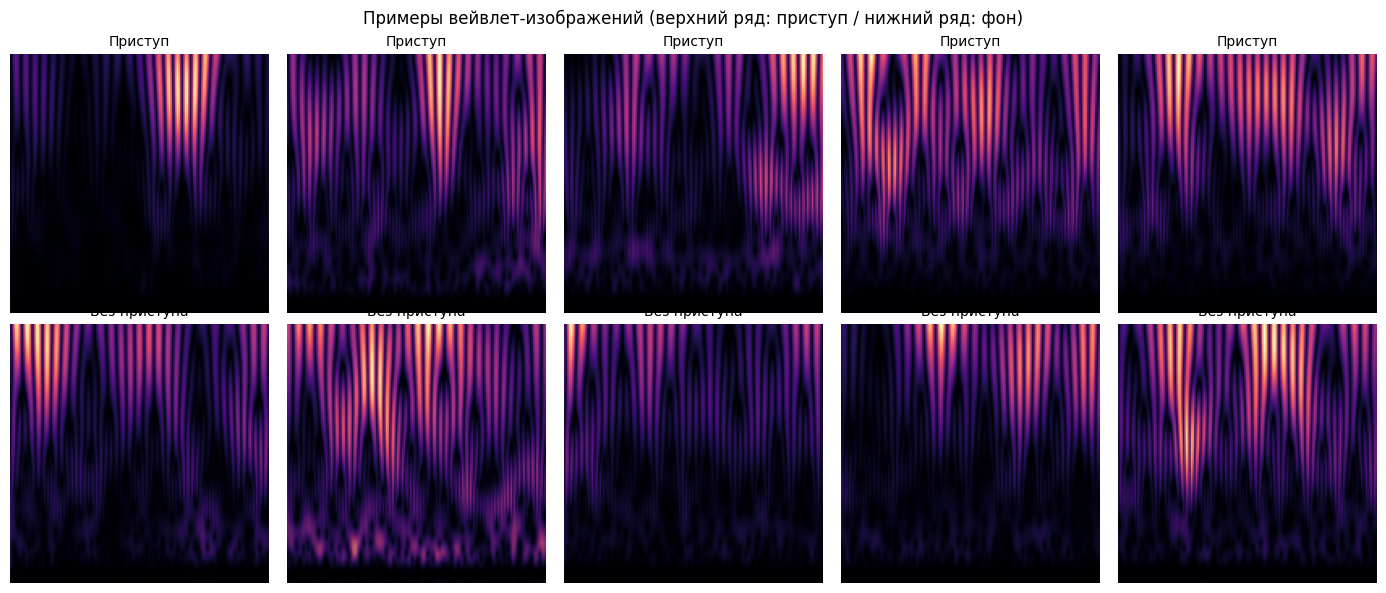

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, item in zip(axes.ravel(), sample_scalograms[:10]):
    path, label = item
    ax.imshow(Image.open(path))
    ax.set_title(label, fontsize=10)
    ax.axis("off")

plt.suptitle("Примеры вейвлет-изображений (верхний ряд: приступ / нижний ряд: фон)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "sample_scalograms.png", dpi=180)
plt.show()


## 6. Обучение


In [11]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.ToTensor(),
])

full_ds = ImageFolder(IMG_ROOT, transform=transform)
class_names = full_ds.classes
targets = np.array(full_ds.targets)

indices = np.arange(len(full_ds))
train_idx, tmp_idx = train_test_split(indices, test_size=0.30, random_state=SEED, stratify=targets)
tmp_targets = targets[tmp_idx]
val_idx, test_idx = train_test_split(tmp_idx, test_size=0.50, random_state=SEED, stratify=tmp_targets)

class SubsetWrap(Dataset):
    def __init__(self, base_ds, indices):
        self.base_ds = base_ds
        self.indices = list(indices)
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        return self.base_ds[self.indices[idx]]

train_ds = SubsetWrap(full_ds, train_idx)
val_ds = SubsetWrap(full_ds, val_idx)
test_ds = SubsetWrap(full_ds, test_idx)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

print("Classes:", class_names)
print("Train / Val / Test:", len(train_ds), len(val_ds), len(test_ds))


Classes: ['non_seizure', 'seizure']
Train / Val / Test: 84 18 18


## 7. Оценка на тестовой выборке


In [12]:
class EEGWaveletCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=3, padding=1),
            nn.BatchNorm2d(24),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(24, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(48, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((5, 5))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(96 * 5 * 5, 128),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x).squeeze(1)

model = EEGWaveletCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=8e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)

print(model)


EEGWaveletCNN(
  (features): Sequential(
    (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(48, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(5, 5))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2400, out_featur

In [13]:
def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    losses = []
    all_true, all_pred = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.float().to(device)

        with torch.set_grad_enabled(train_mode):
            logits = model(x)
            loss = criterion(logits, y)
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).long()

        losses.append(loss.item())
        all_true.extend(y.cpu().numpy().astype(int).tolist())
        all_pred.extend(preds.cpu().numpy().astype(int).tolist())

    acc = accuracy_score(all_true, all_pred)
    return np.mean(losses), acc, all_true, all_pred

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")

for epoch in range(1, 31):
    train_loss, train_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, _, _ = run_epoch(model, val_loader, criterion, None)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_DIR / "best_model_variant.pth")

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} | train_acc={train_acc:.3f} val_acc={val_acc:.3f}")


Epoch 01 | train_loss=0.8035 val_loss=0.6722 | train_acc=0.512 val_acc=0.500
Epoch 02 | train_loss=0.8399 val_loss=0.7761 | train_acc=0.536 val_acc=0.500
Epoch 03 | train_loss=0.6661 val_loss=0.9345 | train_acc=0.583 val_acc=0.500
Epoch 04 | train_loss=0.6642 val_loss=0.8777 | train_acc=0.560 val_acc=0.556
Epoch 05 | train_loss=0.6634 val_loss=0.8783 | train_acc=0.655 val_acc=0.556
Epoch 06 | train_loss=0.6075 val_loss=1.0882 | train_acc=0.667 val_acc=0.500
Epoch 07 | train_loss=0.6642 val_loss=1.0990 | train_acc=0.631 val_acc=0.556
Epoch 08 | train_loss=0.5903 val_loss=0.9371 | train_acc=0.679 val_acc=0.500
Epoch 09 | train_loss=0.6397 val_loss=0.8548 | train_acc=0.583 val_acc=0.611
Epoch 10 | train_loss=0.6810 val_loss=1.0059 | train_acc=0.726 val_acc=0.556
Epoch 11 | train_loss=0.5741 val_loss=0.9462 | train_acc=0.786 val_acc=0.556
Epoch 12 | train_loss=0.5185 val_loss=0.9255 | train_acc=0.798 val_acc=0.611
Epoch 13 | train_loss=0.5193 val_loss=0.9579 | train_acc=0.762 val_acc=0.611

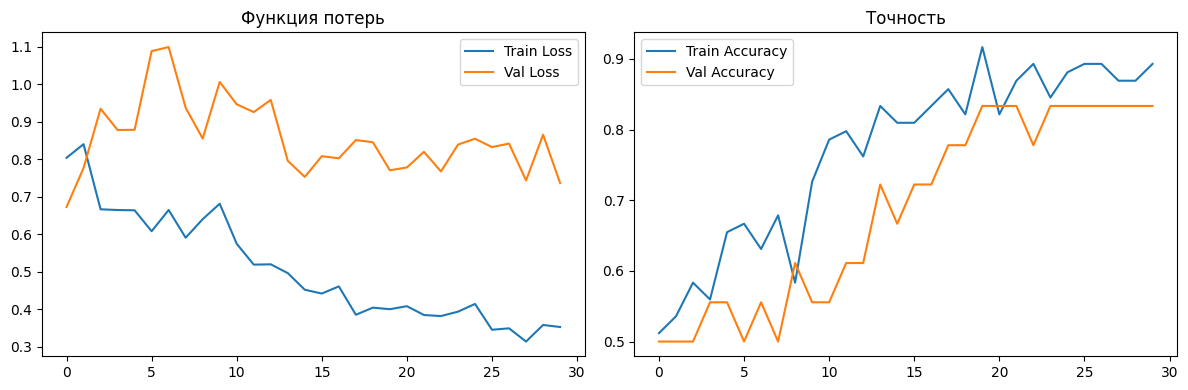

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["train_loss"], label="Train Loss")
ax[0].plot(history["val_loss"], label="Val Loss")
ax[0].set_title("Функция потерь")
ax[0].legend()

ax[1].plot(history["train_acc"], label="Train Accuracy")
ax[1].plot(history["val_acc"], label="Val Accuracy")
ax[1].set_title("Точность")
ax[1].legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / "training_curves.png", dpi=180)
plt.show()


In [15]:
model.load_state_dict(torch.load(MODEL_DIR / "best_model_variant.pth", map_location=device))
test_loss, test_acc, y_true, y_pred = run_epoch(model, test_loader, criterion, None)

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
cm = confusion_matrix(y_true, y_pred)

results = {
    "patient": "chb08",
    "seizure_files": SEIZURE_FILES,
    "background_files": BACKGROUND_FILES,
    "segment_sec": SEGMENT_SEC,
    "images_per_class": TARGET_PER_CLASS,
    "img_size": IMG_SIZE,
    "accuracy": float(test_acc),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "confusion_matrix": cm.tolist(),
    "train_size": len(train_ds),
    "val_size": len(val_ds),
    "test_size": len(test_ds),
}

with open(WORK_DIR / "evaluation_results_variant.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

results


{'patient': 'chb08',
 'seizure_files': ['chb08_11.edf', 'chb08_13.edf', 'chb08_21.edf'],
 'background_files': ['chb08_12.edf', 'chb08_14.edf', 'chb08_15.edf'],
 'segment_sec': 3,
 'images_per_class': 60,
 'img_size': 160,
 'accuracy': 0.5,
 'precision': 0.5,
 'recall': 1.0,
 'f1_score': 0.6666666666666666,
 'confusion_matrix': [[0, 9], [0, 9]],
 'train_size': 84,
 'val_size': 18,
 'test_size': 18}

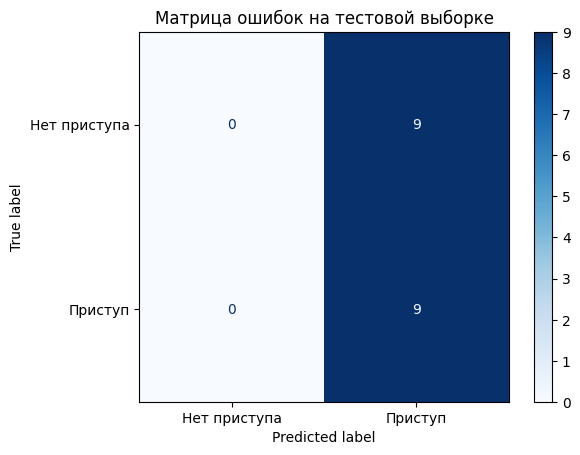

In [16]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Нет приступа", "Приступ"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Матрица ошибок на тестовой выборке")
plt.savefig(PLOTS_DIR / "confusion_matrix.png", dpi=180)
plt.show()
